# ВЭС — clean pipeline 7.44 research style

Стабильная версия без экспериментальных блоков:

```text
safe_features + cluster_axis + layout_wake_risk_scalar_120m
```

Итоговый файл сохраняется в:

```text
outputs/pipeline_744/submission_744.csv
```

Структура сделана линейной: настройки каждого блока идут сразу после markdown-описания блока.

## 0. Импорты и глобальные настройки

In [1]:
# -*- coding: utf-8 -*-

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.interpolate import PchipInterpolator
from scipy.spatial.distance import pdist, squareform

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

In [2]:
RANDOM_STATE = 42

INSTALLED_CAPACITY_MW = 90.09
TURBINES_TOTAL = 26

CUT_IN_SPEED = 3.0
RATED_SPEED = 12.0
CUT_OUT_SPEED = 25.0

AIR_DENSITY_REF = 1.225
EPS = 1e-6

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs") / "pipeline_744"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CANDIDATES = [
    DATA_DIR / "merged_dataset.csv",
    DATA_DIR / "train_dataset.csv",
]

VALID_CANDIDATES = [
    DATA_DIR / "merged_valid_dataset.csv",
    DATA_DIR / "valid_features.csv",
]

TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if p.exists()), TRAIN_CANDIDATES[0])
VALID_PATH = next((p for p in VALID_CANDIDATES if p.exists()), VALID_CANDIDATES[0])

TURBINE_COORDS_PATH = Path("map") / "wind_data" / "wind_farm_cords.csv"
SUBMISSION_PATH = OUTPUT_DIR / "submission_744.csv"

print("TRAIN_PATH:", TRAIN_PATH)
print("VALID_PATH:", VALID_PATH)
print("TURBINE_COORDS_PATH:", TURBINE_COORDS_PATH)
print("SUBMISSION_PATH:", SUBMISSION_PATH)

TRAIN_PATH: data\merged_dataset.csv
VALID_PATH: data\merged_valid_dataset.csv
TURBINE_COORDS_PATH: map\wind_data\wind_farm_cords.csv
SUBMISSION_PATH: outputs\pipeline_744\submission_744.csv


## 1. Загрузка данных

В этом блоке приводим разные возможные названия колонок к единому виду:

```text
datetime
target
turbines_in_repair
```

In [3]:
TARGET_CANDIDATES = [
    "Выработка. Результирующий расчет",
    "target",
    "Выработка",
]

DATETIME_CANDIDATES = [
    "METEOFORECASTHOUR_OPENM_Datetime",
    "Datetime",
    "datetime",
    "date",
    "time",
]

REPAIR_CANDIDATES = [
    "Кол-во_ВЭУ_в_ремонте",
    "turbines_in_repair",
    "repair",
]

In [4]:
print("1. Загрузка данных...")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Не найден train-файл: {TRAIN_PATH}")

if not VALID_PATH.exists():
    raise FileNotFoundError(f"Не найден valid-файл: {VALID_PATH}")

train_raw = pd.read_csv(TRAIN_PATH)
valid_raw = pd.read_csv(VALID_PATH)

print("train_raw:", train_raw.shape)
print("valid_raw:", valid_raw.shape)

target_col = None
for col in TARGET_CANDIDATES:
    if col in train_raw.columns and col not in valid_raw.columns:
        target_col = col
        break

if target_col is None:
    diff_cols = [c for c in train_raw.columns if c not in valid_raw.columns]
    if len(diff_cols) == 0:
        raise ValueError("Не найден target.")
    target_col = diff_cols[0]

datetime_col = None
for col in DATETIME_CANDIDATES:
    if col in train_raw.columns and col in valid_raw.columns:
        datetime_col = col
        break

if datetime_col is None:
    raise ValueError("Не найдена datetime-колонка.")

repair_col = None
for col in REPAIR_CANDIDATES:
    if col in train_raw.columns and col in valid_raw.columns:
        repair_col = col
        break

if repair_col is None:
    common_cols = [c for c in train_raw.columns if c in valid_raw.columns]
    repair_col = common_cols[-1]

print("target_col:", target_col)
print("datetime_col:", datetime_col)
print("repair_col:", repair_col)

train = train_raw.rename(
    columns={
        datetime_col: "datetime",
        target_col: "target",
        repair_col: "turbines_in_repair",
    }
).copy()

valid = valid_raw.rename(
    columns={
        datetime_col: "datetime",
        repair_col: "turbines_in_repair",
    }
).copy()

if not train.columns.is_unique:
    print("Дубли колонок в train:", train.columns[train.columns.duplicated()].tolist())
    train = train.loc[:, ~train.columns.duplicated()].copy()

if not valid.columns.is_unique:
    print("Дубли колонок в valid:", valid.columns[valid.columns.duplicated()].tolist())
    valid = valid.loc[:, ~valid.columns.duplicated()].copy()

train["datetime"] = pd.to_datetime(train["datetime"], errors="coerce")
valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")

train["row_id"] = np.arange(len(train))
valid["row_id"] = np.arange(len(valid))

train["source"] = "train"
valid["source"] = "valid"

train = train.sort_values("datetime").reset_index(drop=True)
valid = valid.sort_values("datetime").reset_index(drop=True)

print("train:", train.shape)
print("valid:", valid.shape)
display(train.head())
display(valid.head())

1. Загрузка данных...
train_raw: (32434, 36)
valid_raw: (2126, 35)
target_col: Выработка. Результирующий расчет
datetime_col: METEOFORECASTHOUR_OPENM_Datetime
repair_col: Кол-во_ВЭУ_в_ремонте
train: (32434, 38)
valid: (2126, 37)


,datetime,month,hour_of_day,target,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,wind_direction_120m,wind_direction_180m,wind_gusts_10m,temperature_80m,temperature_120m,pressure_msl,rain,showers,snowfall,cloud_cover_low,turbines_in_repair,Datetime,YEAR,MO,DY,HR,T2MDEW,T2M,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC,row_id,source
0,2022-01-01 00:00:00,1,0,0.697,2.77,4.27,4.62,NaN,0.244,0.249,0.252,NaN,5.2,0.8,0.6,1016.9,0.0,0.0,0.0,0.081,3,2022-01-01 00:00:00,2022,1,1,0,-3.12,-1.36,2.98,101.36,1.70,272.4,2.07,271.9,-2.24,2.87,32433,train
1,2022-01-01 01:00:00,1,1,4.413,2.91,4.40,4.78,NaN,0.243,0.249,0.250,NaN,5.5,0.7,0.6,1016.7,0.0,0.0,0.0,0.081,3,2022-01-01 01:00:00,2022,1,1,1,-3.10,-1.34,2.99,101.32,2.10,259.0,2.59,258.6,-2.22,3.59,32432,train
2,2022-01-01 02:00:00,1,2,5.362,3.11,4.92,5.36,NaN,0.237,0.246,0.249,NaN,5.7,0.6,0.5,1016.6,0.0,0.0,0.0,0.023,3,2022-01-01 02:00:00,2022,1,1,2,-3.06,-1.41,3.00,101.30,2.69,248.9,3.38,248.5,-2.23,4.68,32431,train
3,2022-01-01 03:00:00,1,3,4.879,3.02,4.66,5.14,NaN,0.236,0.247,0.249,NaN,5.8,0.6,0.5,1016.4,0.0,0.0,0.0,0.072,3,2022-01-01 03:00:00,2022,1,1,3,-2.93,-1.43,3.03,101.26,3.28,240.2,4.19,240.1,-2.18,5.80,32430,train
4,2022-01-01 04:00:00,1,4,6.309,3.26,4.50,4.82,NaN,0.220,0.233,0.234,NaN,6.9,0.4,0.3,1015.7,0.0,0.0,0.0,0.100,3,2022-01-01 04:00:00,2022,1,1,4,-2.65,-1.34,3.10,101.22,3.76,232.5,4.87,232.4,-2.00,6.75,32429,train


,datetime,month,hour_of_day,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,wind_direction_120m,wind_direction_180m,wind_gusts_10m,temperature_80m,temperature_120m,pressure_msl,rain,showers,snowfall,cloud_cover_low,turbines_in_repair,Datetime,YEAR,MO,DY,HR,T2MDEW,T2M,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC,row_id,source
0,2026-01-01 00:00:00,1,0,4.02,6.80,7.70,8.11,0.264,0.270,0.271,0.272,7.1,-3.8,-4.4,1008.2,0.0,0.0,0.0,0.023,3,2026-01-01 00:00:00,2026,1,1,0,-8.00,-3.80,2.01,100.49,6.52,258.4,9.17,258.7,-5.90,12.70,2125,valid
1,2026-01-01 01:00:00,1,1,3.76,6.66,7.83,8.42,0.253,0.262,0.265,0.266,6.3,-3.8,-4.2,1008.2,0.0,0.0,0.0,0.025,3,2026-01-01 01:00:00,2026,1,1,1,-7.63,-3.70,2.08,100.52,6.66,255.6,9.29,255.9,-5.67,12.87,2124,valid
2,2026-01-01 02:00:00,1,2,3.45,6.86,8.97,10.08,0.240,0.251,0.256,0.259,6.0,-3.6,-3.8,1008.9,0.0,0.0,0.0,0.100,3,2026-01-01 02:00:00,2026,1,1,2,-7.09,-3.49,2.17,100.56,6.83,255.3,9.43,255.8,-5.29,13.06,2123,valid
3,2026-01-01 03:00:00,1,3,4.14,7.45,9.31,10.57,0.250,0.258,0.261,0.263,5.9,-3.2,-3.6,1009.4,0.0,0.0,0.0,0.088,3,2026-01-01 03:00:00,2026,1,1,3,-6.47,-3.46,2.29,100.60,6.86,260.1,9.31,260.5,-4.96,12.90,2122,valid
4,2026-01-01 04:00:00,1,4,4.63,7.98,9.33,10.11,0.256,0.262,0.265,0.267,7.4,-3.2,-3.7,1009.5,0.0,0.0,0.0,0.079,3,2026-01-01 04:00:00,2026,1,1,4,-6.15,-3.78,2.35,100.64,6.63,267.9,8.92,268.2,-4.97,12.36,2121,valid


## 2. Базовая генерация признаков

Здесь создаются только проверенные базовые и safe-признаки: время, ветер, сухая плотность воздуха, теоретическая кривая, shear, cap13, сектора направления и расхождение NASA/OpenM.

In [5]:
SPEED_COLS_RAW = [
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
]

DIRECTION_COLS_RAW = [
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
]

SHEAR_HEIGHT_PAIRS = [
    (10, 80),
    (80, 120),
    (120, 180),
    (80, 180),
    (10, 120),
]

DIRECTION_SECTOR_HEIGHTS = [80, 120, 180]
DIRECTION_SECTOR_COUNTS = [8, 16]

CAP_SPEED_HEIGHT = 120
CAP_SPEED_VALUE = 13

WEATHER_FEATURE_BLOCKS = {
    "shear": [],
    "cap13": [],
    "direction_sectors": [],
    "nasa_openm_disagreement": [],
    "isotonic": [],
    "density_humidity": [],
}

In [6]:
print("2. Генерация базовых признаков...")

full = pd.concat([train, valid], ignore_index=True, sort=False)
full = full.sort_values("datetime").reset_index(drop=True)

# ------------------------------------------------------------
# Время
# ------------------------------------------------------------

full["month"] = full["datetime"].dt.month
full["hour_of_day"] = full["datetime"].dt.hour
full["dayofyear"] = full["datetime"].dt.dayofyear
full["dayofweek"] = full["datetime"].dt.dayofweek

full["hour_sin"] = np.sin(2 * np.pi * full["hour_of_day"] / 24)
full["hour_cos"] = np.cos(2 * np.pi * full["hour_of_day"] / 24)

full["month_sin"] = np.sin(2 * np.pi * full["month"] / 12)
full["month_cos"] = np.cos(2 * np.pi * full["month"] / 12)

full["dayofyear_sin"] = np.sin(2 * np.pi * full["dayofyear"] / 366)
full["dayofyear_cos"] = np.cos(2 * np.pi * full["dayofyear"] / 366)

# ------------------------------------------------------------
# Ветер
# ------------------------------------------------------------

speed_cols = [c for c in SPEED_COLS_RAW if c in full.columns]
direction_cols = [c for c in DIRECTION_COLS_RAW if c in full.columns]

for col in speed_cols:
    full[f"{col}_sq"] = full[col] ** 2
    full[f"{col}_cube"] = full[col] ** 3

for col in direction_cols:
    suffix = col.replace("wind_direction_", "")
    angle = np.deg2rad(full[col] * 1000)
    full[f"wind_dir_{suffix}_sin"] = np.sin(angle)
    full[f"wind_dir_{suffix}_cos"] = np.cos(angle)

if "wind_speed_120m" in full.columns:
    full["ws_120_cube"] = full["wind_speed_120m"] ** 3

if {"wind_speed_120m", "wind_speed_80m"}.issubset(full.columns):
    full["ws_diff_120_80"] = full["wind_speed_120m"] - full["wind_speed_80m"]
    full["ws_ratio_120_80"] = full["wind_speed_120m"] / (full["wind_speed_80m"] + EPS)

if {"wind_speed_180m", "wind_speed_120m"}.issubset(full.columns):
    full["ws_diff_180_120"] = full["wind_speed_180m"] - full["wind_speed_120m"]

if {"wind_gusts_10m", "wind_speed_10m"}.issubset(full.columns):
    full["gust_ratio_10m"] = full["wind_gusts_10m"] / (full["wind_speed_10m"] + EPS)

# ------------------------------------------------------------
# Сухая плотность воздуха и density-corrected speed
# ------------------------------------------------------------

required_density_cols = {"temperature_80m", "temperature_120m", "pressure_msl"}
if required_density_cols.issubset(full.columns):
    temperature_mean = 0.5 * (full["temperature_80m"] + full["temperature_120m"])
    temperature_mean_k = temperature_mean + 273.15
    pressure_pa = full["pressure_msl"] * 100

    full["air_density"] = pressure_pa / (287.05 * temperature_mean_k)
    full["density_ratio"] = (full["air_density"] / AIR_DENSITY_REF).clip(0.75, 1.30)

    WEATHER_FEATURE_BLOCKS["density_humidity"] += [
        "air_density",
        "density_ratio",
    ]

    for height in [80, 120]:
        speed_col = f"wind_speed_{height}m"
        if speed_col in full.columns:
            full[f"wind_speed_{height}m_density_corrected"] = (
                full[speed_col] * (full["density_ratio"] ** (1 / 3))
            )
            full[f"wind_power_density_{height}m"] = (
                0.5 * full["air_density"] * full[speed_col] ** 3
            )

            WEATHER_FEATURE_BLOCKS["density_humidity"] += [
                f"wind_speed_{height}m_density_corrected",
                f"wind_power_density_{height}m",
            ]

for col in WEATHER_FEATURE_BLOCKS["density_humidity"]:
    if col in full.columns:
        full[col] = full[col].replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# Доступность ВЭС
# ------------------------------------------------------------

full["turbines_in_repair"] = pd.to_numeric(full["turbines_in_repair"], errors="coerce")

availability = (
    (TURBINES_TOTAL - full["turbines_in_repair"])
    .clip(0, TURBINES_TOTAL)
    / TURBINES_TOTAL
)

full["available_capacity_mw"] = availability * INSTALLED_CAPACITY_MW

# ------------------------------------------------------------
# Теоретическая кривая мощности
# ------------------------------------------------------------

for height in [80, 120]:
    speed_col = f"wind_speed_{height}m"

    if speed_col in full.columns:
        speed = full[speed_col].clip(lower=0)

        curve = (
            (speed ** 3 - CUT_IN_SPEED ** 3)
            / (RATED_SPEED ** 3 - CUT_IN_SPEED ** 3)
        ).clip(0, 1)

        curve = curve.where(speed >= CUT_IN_SPEED, 0)
        curve = curve.where(speed < CUT_OUT_SPEED, 0)

        full[f"p_theory_{height}"] = INSTALLED_CAPACITY_MW * curve * availability

if {"p_theory_80", "p_theory_120"}.issubset(full.columns):
    full["p_theory_mean_80_120"] = 0.5 * (full["p_theory_80"] + full["p_theory_120"])

# ------------------------------------------------------------
# Safe block: shear
# ------------------------------------------------------------

def add_shear_feature(df, low_h, high_h):
    low_col = f"wind_speed_{low_h}m"
    high_col = f"wind_speed_{high_h}m"
    out_col = f"shear_{low_h}_{high_h}"

    if low_col in df.columns and high_col in df.columns:
        df[out_col] = (
            np.log((df[high_col].clip(lower=EPS)) / (df[low_col].clip(lower=EPS)))
            / np.log(high_h / low_h)
        )
        df[out_col] = df[out_col].replace([np.inf, -np.inf], np.nan)
        WEATHER_FEATURE_BLOCKS["shear"].append(out_col)

for low_h, high_h in SHEAR_HEIGHT_PAIRS:
    add_shear_feature(full, low_h, high_h)

# ------------------------------------------------------------
# Safe block: cap13
# ------------------------------------------------------------

cap_col = f"wind_speed_{CAP_SPEED_HEIGHT}m"
if cap_col in full.columns:
    base = f"wind{CAP_SPEED_HEIGHT}_cap{CAP_SPEED_VALUE}"

    full[f"{base}_clipped"] = full[cap_col].clip(upper=CAP_SPEED_VALUE)
    full[f"{base}_above"] = (full[cap_col] - CAP_SPEED_VALUE).clip(lower=0)
    full[f"{base}_is_above"] = (full[cap_col] > CAP_SPEED_VALUE).astype(int)
    full[f"{base}_clipped_cube"] = full[f"{base}_clipped"] ** 3

    WEATHER_FEATURE_BLOCKS["cap13"] += [
        f"{base}_clipped",
        f"{base}_above",
        f"{base}_is_above",
        f"{base}_clipped_cube",
    ]

# ------------------------------------------------------------
# Safe block: direction sectors
# ------------------------------------------------------------

for height in DIRECTION_SECTOR_HEIGHTS:
    col = f"wind_direction_{height}m"

    if col in full.columns:
        deg = (full[col] * 1000) % 360

        for n_sec in DIRECTION_SECTOR_COUNTS:
            sec_col = f"wind_dir_{height}m_sector_{n_sec}"

            sector = np.floor(deg / (360 / n_sec))
            sector = (
                sector
                .replace([np.inf, -np.inf], np.nan)
                .fillna(-1)
                .clip(-1, n_sec - 1)
                .astype(int)
            )

            full[sec_col] = sector
            WEATHER_FEATURE_BLOCKS["direction_sectors"].append(sec_col)

# ------------------------------------------------------------
# Safe block: NASA/OpenM disagreement
# ------------------------------------------------------------

def add_diff_if_possible(openm_col, nasa_col, new_col):
    if openm_col in full.columns and nasa_col in full.columns:
        full[new_col] = full[openm_col] - full[nasa_col]
        full[new_col] = full[new_col].replace([np.inf, -np.inf], np.nan)
        WEATHER_FEATURE_BLOCKS["nasa_openm_disagreement"].append(new_col)

add_diff_if_possible("wind_speed_10m", "WS10M", "ws10_openm_minus_nasa")
add_diff_if_possible("wind_speed_80m", "WS50M", "ws80_openm_minus_nasa50")
add_diff_if_possible("pressure_msl", "PS", "pressure_msl_minus_ps")
add_diff_if_possible("temperature_80m", "T2M", "temp80_minus_t2m")

if "wind_direction_10m" in full.columns and "WD10M" in full.columns:
    openm_deg = (full["wind_direction_10m"] * 1000) % 360
    nasa_deg = full["WD10M"] % 360

    diff = ((openm_deg - nasa_deg + 180) % 360) - 180
    full["wd10_openm_minus_nasa_circular"] = diff.replace([np.inf, -np.inf], np.nan)

    WEATHER_FEATURE_BLOCKS["nasa_openm_disagreement"].append("wd10_openm_minus_nasa_circular")

for block_name in WEATHER_FEATURE_BLOCKS:
    WEATHER_FEATURE_BLOCKS[block_name] = sorted(list(dict.fromkeys(WEATHER_FEATURE_BLOCKS[block_name])))

print("full:", full.shape)
for block_name, cols in WEATHER_FEATURE_BLOCKS.items():
    print(block_name, len(cols), cols)

2. Генерация базовых признаков...
full: (34560, 97)
shear 5 ['shear_10_120', 'shear_10_80', 'shear_120_180', 'shear_80_120', 'shear_80_180']
cap13 4 ['wind120_cap13_above', 'wind120_cap13_clipped', 'wind120_cap13_clipped_cube', 'wind120_cap13_is_above']
direction_sectors 6 ['wind_dir_120m_sector_16', 'wind_dir_120m_sector_8', 'wind_dir_180m_sector_16', 'wind_dir_180m_sector_8', 'wind_dir_80m_sector_16', 'wind_dir_80m_sector_8']
nasa_openm_disagreement 5 ['pressure_msl_minus_ps', 'temp80_minus_t2m', 'wd10_openm_minus_nasa_circular', 'ws10_openm_minus_nasa', 'ws80_openm_minus_nasa50']
isotonic 0 []
density_humidity 6 ['air_density', 'density_ratio', 'wind_power_density_120m', 'wind_power_density_80m', 'wind_speed_120m_density_corrected', 'wind_speed_80m_density_corrected']


## 3. EMA и NWP-соседи

Сглаживания и соседние прогнозные значения остаются частью стабильного safe pipeline.

In [7]:
EWM_SPANS = {
    "3h": 3,
    "5h": 5,
    "7h": 7,
}

EMA_SOURCE_COLS = [
    "wind_speed_120m_cube",
    "p_theory_80",
    "p_theory_120",
    "wind_power_density_120m",
]

NWP_SHIFTS = [-6, -3, -2, -1, 1, 2, 3, 6]

NWP_BASE_COLS = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_cube",
    "wind_speed_120m_density_corrected",
    "p_theory_120",
    "wind_power_density_120m",
]

In [8]:
print("3. EMA и NWP-соседи...")

full = full.sort_values("datetime").reset_index(drop=True)
time_indexed = full.set_index("datetime")

ema_cols = [c for c in EMA_SOURCE_COLS if c in full.columns]

for col in ema_cols:
    for window_str, span_val in EWM_SPANS.items():
        full[f"{col}_smooth_{window_str}"] = (
            time_indexed[col]
            .ewm(span=span_val, min_periods=1)
            .mean()
            .reindex(full["datetime"])
            .to_numpy()
        )

    full[f"{col}_minus_smooth_3h"] = full[col] - full[f"{col}_smooth_3h"]

nwp_base_cols = [c for c in NWP_BASE_COLS if c in full.columns]

for col in nwp_base_cols:
    for shift_hours in NWP_SHIFTS:
        shifted_datetime = full["datetime"] + pd.to_timedelta(shift_hours, unit="h")
        label = f"plus_{shift_hours}h" if shift_hours > 0 else f"minus_{abs(shift_hours)}h"

        full[f"{col}_nwp_{label}"] = (
            time_indexed[col]
            .reindex(shifted_datetime)
            .to_numpy()
        )

print("full:", full.shape)

3. EMA и NWP-соседи...
full: (34560, 161)


## 4. Эмпирическая кривая мощности

`p_empirical_mean_80_120` — обязательная базовая колонка для residual-моделей ансамбля.

In [9]:
EMPIRICAL_SPEED_HEIGHTS = [80, 120]
EMPIRICAL_SPEED_BINS = np.arange(0, 26.5, 0.5)
EMPIRICAL_MIN_BIN_COUNT = 20
EMPIRICAL_CF_MAX = 1.15

In [10]:
print("4. Эмпирическая кривая мощности...")

train_base = (
    full[full["source"].eq("train")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

valid_base = (
    full[full["source"].eq("valid")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

def add_empirical_power_features(frame, reference):
    frame = frame.copy()
    reference = reference.copy()

    ref_available = reference["available_capacity_mw"].clip(lower=1.0)
    reference["cf_available"] = (reference["target"] / ref_available).clip(0, EMPIRICAL_CF_MAX)

    iso_cols = []

    for height in EMPIRICAL_SPEED_HEIGHTS:
        speed_col = f"wind_speed_{height}m_density_corrected"

        if speed_col not in frame.columns or speed_col not in reference.columns:
            print(f"WARN: нет {speed_col}, пропускаю p_empirical_{height}")
            continue

        ref = reference[[speed_col, "cf_available"]].dropna().copy()
        ref["bin_id"] = pd.cut(ref[speed_col], bins=EMPIRICAL_SPEED_BINS, labels=False)

        curve = (
            ref.groupby("bin_id", as_index=False)
            .agg(
                cf=("cf_available", "median"),
                n=("cf_available", "size"),
            )
        )

        curve = curve[curve["n"] >= EMPIRICAL_MIN_BIN_COUNT].copy()
        curve["speed"] = EMPIRICAL_SPEED_BINS[curve["bin_id"].astype(int)] + 0.25
        curve = curve.sort_values("speed")

        if len(curve) == 0:
            frame[f"p_empirical_{height}"] = 0.0
            frame[f"cf_empirical_{height}"] = 0.0
            frame[f"p_empirical_iso_{height}"] = 0.0
            frame[f"cf_empirical_iso_{height}"] = 0.0

            iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]
            continue

        cf_monotonic = np.maximum.accumulate(curve["cf"].to_numpy())

        x = np.r_[0.0, curve["speed"].to_numpy(), CUT_OUT_SPEED]
        y = np.r_[0.0, cf_monotonic, cf_monotonic[-1]]

        unique_x, unique_idx = np.unique(x, return_index=True)
        unique_y = y[unique_idx]

        interpolator = PchipInterpolator(unique_x, unique_y, extrapolate=True)

        speed_eval = frame[speed_col].clip(0, CUT_OUT_SPEED)

        empirical_cf = np.clip(interpolator(speed_eval), 0, EMPIRICAL_CF_MAX)
        empirical_cf = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf)
        empirical_cf = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf)

        frame[f"p_empirical_{height}"] = empirical_cf * frame["available_capacity_mw"]
        frame[f"cf_empirical_{height}"] = empirical_cf

        iso = IsotonicRegression(
            y_min=0.0,
            y_max=EMPIRICAL_CF_MAX,
            increasing=True,
            out_of_bounds="clip",
        )

        iso.fit(curve["speed"].to_numpy(), curve["cf"].to_numpy())

        empirical_cf_iso = np.clip(iso.predict(speed_eval), 0, EMPIRICAL_CF_MAX)
        empirical_cf_iso = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf_iso)
        empirical_cf_iso = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf_iso)

        frame[f"p_empirical_iso_{height}"] = empirical_cf_iso * frame["available_capacity_mw"]
        frame[f"cf_empirical_iso_{height}"] = empirical_cf_iso

        iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]

    if {"p_empirical_80", "p_empirical_120"}.issubset(frame.columns):
        frame["p_empirical_mean_80_120"] = 0.5 * (
            frame["p_empirical_80"] + frame["p_empirical_120"]
        )

    if {"p_empirical_iso_80", "p_empirical_iso_120"}.issubset(frame.columns):
        frame["p_empirical_iso_mean_80_120"] = 0.5 * (
            frame["p_empirical_iso_80"] + frame["p_empirical_iso_120"]
        )
        iso_cols.append("p_empirical_iso_mean_80_120")

    if {"p_empirical_120", "p_theory_120"}.issubset(frame.columns):
        frame["p_empirical_minus_theory_120"] = frame["p_empirical_120"] - frame["p_theory_120"]

    return frame, sorted(list(dict.fromkeys(iso_cols)))


train_fe, iso_train_cols = add_empirical_power_features(train_base, train_base)
valid_fe, iso_valid_cols = add_empirical_power_features(valid_base, train_base)

WEATHER_FEATURE_BLOCKS["isotonic"] = sorted(
    list(set(iso_train_cols).intersection(set(iso_valid_cols)))
)

print("train_fe:", train_fe.shape)
print("valid_fe:", valid_fe.shape)
print("isotonic:", WEATHER_FEATURE_BLOCKS["isotonic"])
print("p_empirical cols:", [c for c in train_fe.columns if "p_empirical" in c])

if "p_empirical_mean_80_120" not in train_fe.columns:
    raise RuntimeError(
        "Не создалась p_empirical_mean_80_120. Проверь density-corrected признаки."
    )

4. Эмпирическая кривая мощности...
train_fe: (32434, 172)
valid_fe: (2126, 172)
isotonic: ['cf_empirical_iso_120', 'cf_empirical_iso_80', 'p_empirical_iso_120', 'p_empirical_iso_80', 'p_empirical_iso_mean_80_120']
p_empirical cols: ['p_empirical_80', 'p_empirical_iso_80', 'p_empirical_120', 'p_empirical_iso_120', 'p_empirical_mean_80_120', 'p_empirical_iso_mean_80_120', 'p_empirical_minus_theory_120']


## 5. Выбор признаков

Формируем `safe_features`: базовые признаки + проверенные safe-блоки.

In [11]:
RAW_FEATURE_COLS = [
    "month",
    "hour_of_day",
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
    "wind_gusts_10m",
    "temperature_80m",
    "temperature_120m",
    "pressure_msl",
    "rain",
    "showers",
    "snowfall",
    "cloud_cover_low",
    "turbines_in_repair",
]

PHYSICS_FEATURE_COLS = [
    "available_capacity_mw",
    "air_density",
    "density_ratio",
    "wind_power_density_80m",
    "wind_power_density_120m",
    "p_theory_80",
    "p_theory_120",
    "p_theory_mean_80_120",
    "p_empirical_80",
    "p_empirical_120",
    "p_empirical_mean_80_120",
    "p_empirical_minus_theory_120",
    "cf_empirical_80",
    "cf_empirical_120",
]

SAFE_EXTRA_BLOCK_ORDER = [
    "shear",
    "cap13",
    "direction_sectors",
    "nasa_openm_disagreement",
    "isotonic",
]

In [12]:
auto_cols = [
    col for col in train_fe.columns
    if (
        col.endswith("_sq")
        or col.endswith("_cube")
        or col.startswith("wind_dir_")
        or "_smooth_" in col
        or col.endswith("_minus_smooth_3h")
        or "_nwp_" in col
        or col.endswith("_density_corrected")
        or col.startswith("ws_")
        or col.startswith("gust_ratio")
        or col.startswith("dayofyear_")
    )
]

feature_candidates = RAW_FEATURE_COLS + PHYSICS_FEATURE_COLS + auto_cols

baseline_features = list(dict.fromkeys([
    c for c in feature_candidates
    if c in train_fe.columns and c in valid_fe.columns
]))

safe_extra_cols = []
for block_name in SAFE_EXTRA_BLOCK_ORDER:
    safe_extra_cols += WEATHER_FEATURE_BLOCKS.get(block_name, [])

safe_extra_cols = list(dict.fromkeys([
    c for c in safe_extra_cols
    if c in train_fe.columns and c in valid_fe.columns
]))

safe_features = list(dict.fromkeys([
    c for c in baseline_features + safe_extra_cols
    if c in train_fe.columns and c in valid_fe.columns
]))

print("baseline_features:", len(baseline_features))
print("safe_extra_cols:", len(safe_extra_cols))
print("safe_features:", len(safe_features))

print("\nSafe-блоки:")
for block_name, cols in WEATHER_FEATURE_BLOCKS.items():
    cols2 = [c for c in cols if c in train_fe.columns and c in valid_fe.columns]
    print(block_name, len(cols2), cols2)

feature_manifest_safe = pd.DataFrame({"feature": safe_features})
display(feature_manifest_safe.tail(20))

baseline_features: 129
safe_extra_cols: 25
safe_features: 147

Safe-блоки:
shear 5 ['shear_10_120', 'shear_10_80', 'shear_120_180', 'shear_80_120', 'shear_80_180']
cap13 4 ['wind120_cap13_above', 'wind120_cap13_clipped', 'wind120_cap13_clipped_cube', 'wind120_cap13_is_above']
direction_sectors 6 ['wind_dir_120m_sector_16', 'wind_dir_120m_sector_8', 'wind_dir_180m_sector_16', 'wind_dir_180m_sector_8', 'wind_dir_80m_sector_16', 'wind_dir_80m_sector_8']
nasa_openm_disagreement 5 ['pressure_msl_minus_ps', 'temp80_minus_t2m', 'wd10_openm_minus_nasa_circular', 'ws10_openm_minus_nasa', 'ws80_openm_minus_nasa50']
isotonic 5 ['cf_empirical_iso_120', 'cf_empirical_iso_80', 'p_empirical_iso_120', 'p_empirical_iso_80', 'p_empirical_iso_mean_80_120']
density_humidity 6 ['air_density', 'density_ratio', 'wind_power_density_120m', 'wind_power_density_80m', 'wind_speed_120m_density_corrected', 'wind_speed_80m_density_corrected']


,feature
127,wind_power_density_120m_nwp_plus_3h
128,wind_power_density_120m_nwp_plus_6h
129,shear_10_120
130,shear_10_80
131,shear_120_180
132,shear_80_120
133,shear_80_180
134,wind120_cap13_above
135,wind120_cap13_clipped
136,wind120_cap13_is_above


## 6. Ансамбль моделей

Фиксированные веса из стабильного pipeline 7.44.

In [13]:
BLEND_WEIGHTS = {
    "cat_mae_direct": 0.361831,
    "hgb_q545": 0.235409,
    "xgb_residual": 0.177644,
    "hgb_q570": 0.116581,
    "lgb_residual": 0.064663,
    "hgb_q530": 0.043873,
}

ENSEMBLE_PARAMS_FULL = {
    "cat_iter": 1200,
    "xgb_estimators": 900,
    "lgb_estimators": 900,
    "hgb_iter": 650,
}

ENSEMBLE_PARAMS_FAST = {
    "cat_iter": 500,
    "xgb_estimators": 450,
    "lgb_estimators": 450,
    "hgb_iter": 350,
}

HGB_QUANTILES = [0.545, 0.570, 0.530]

In [14]:
def fit_ensemble(local_train, feature_cols, label="ensemble", fast_mode=False):
    print(f"\nОбучение ансамбля: {label}")
    print("n_features:", len(feature_cols))

    if "p_empirical_mean_80_120" not in local_train.columns:
        raise KeyError("В local_train нет p_empirical_mean_80_120")

    models = {}

    y_direct = local_train["target"].clip(0, INSTALLED_CAPACITY_MW)
    y_residual = local_train["target"] - local_train["p_empirical_mean_80_120"]
    y_scaled = (local_train["target"] / INSTALLED_CAPACITY_MW).clip(0, 1)

    params = ENSEMBLE_PARAMS_FAST if fast_mode else ENSEMBLE_PARAMS_FULL

    cat = CatBoostRegressor(
        iterations=params["cat_iter"],
        learning_rate=0.03,
        depth=6,
        loss_function="MAE",
        random_seed=RANDOM_STATE,
        verbose=0,
    )
    cat.fit(local_train[feature_cols], y_direct)
    models["cat_mae_direct"] = cat

    xgb = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=params["xgb_estimators"],
        learning_rate=0.025,
        max_depth=5,
        min_child_weight=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
    )
    xgb.fit(local_train[feature_cols], y_residual)
    models["xgb_residual"] = xgb

    lgbm = lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=params["lgb_estimators"],
        learning_rate=0.025,
        num_leaves=31,
        min_child_samples=35,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )
    lgbm.fit(local_train[feature_cols], y_residual)
    models["lgb_residual"] = lgbm

    for q in HGB_QUANTILES:
        model_name = f"hgb_q{int(q * 1000):03d}"

        hgb = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=q,
            max_iter=params["hgb_iter"],
            learning_rate=0.04,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=0.02,
            early_stopping=True,
            validation_fraction=0.12,
            random_state=RANDOM_STATE,
        )

        hgb.fit(local_train[feature_cols], y_scaled)
        models[model_name] = hgb

    return models


def predict_ensemble(models, frame, feature_cols):
    if "p_empirical_mean_80_120" not in frame.columns:
        raise KeyError("В frame нет p_empirical_mean_80_120")

    preds = {}

    preds["cat_mae_direct"] = np.clip(
        models["cat_mae_direct"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    preds["xgb_residual"] = np.clip(
        frame["p_empirical_mean_80_120"].to_numpy()
        + models["xgb_residual"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    preds["lgb_residual"] = np.clip(
        frame["p_empirical_mean_80_120"].to_numpy()
        + models["lgb_residual"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    for q in HGB_QUANTILES:
        model_name = f"hgb_q{int(q * 1000):03d}"

        preds[model_name] = (
            np.clip(models[model_name].predict(frame[feature_cols]), 0, 1)
            * INSTALLED_CAPACITY_MW
        )

    final = np.zeros(len(frame))

    for model_name, weight in BLEND_WEIGHTS.items():
        final += preds[model_name] * weight

    final = np.clip(final, 0, INSTALLED_CAPACITY_MW)

    return final, preds

## 7. Геометрия ВЭС: cluster_axis и wake table

Здесь рассчитывается геометрия парка по координатам турбин, кластеры, оси кластеров и таблица wake-risk по направлениям ветра.

In [15]:
N_LAYOUT_CLUSTERS = 4
LAYOUT_KMEANS_N_INIT = 30

WAKE_DIRECTION_STEP_DEG = 5
WAKE_LATERAL_THRESHOLD_M = 260
WAKE_MAX_DOWNWIND_M = 2500
WAKE_DECAY_DOWNWIND_M = 800

ГЕОМЕТРИЯ ВЭС
Турбин: 26
Среднее ближайшее расстояние: 343.0 м
Медианное ближайшее расстояние: 353.6 м
Главная ось ВЭС: 9.30° / 189.30°
Доля объяснённой дисперсии PCA: [0.69031765 0.30968235]


,cluster_id,cluster_axis_compass_deg,cluster_axis_evr,n
0,0,1.049124,0.999860,6
1,1,0.071119,0.999975,8
2,2,88.689012,0.831549,6
3,3,333.710799,0.965362,6


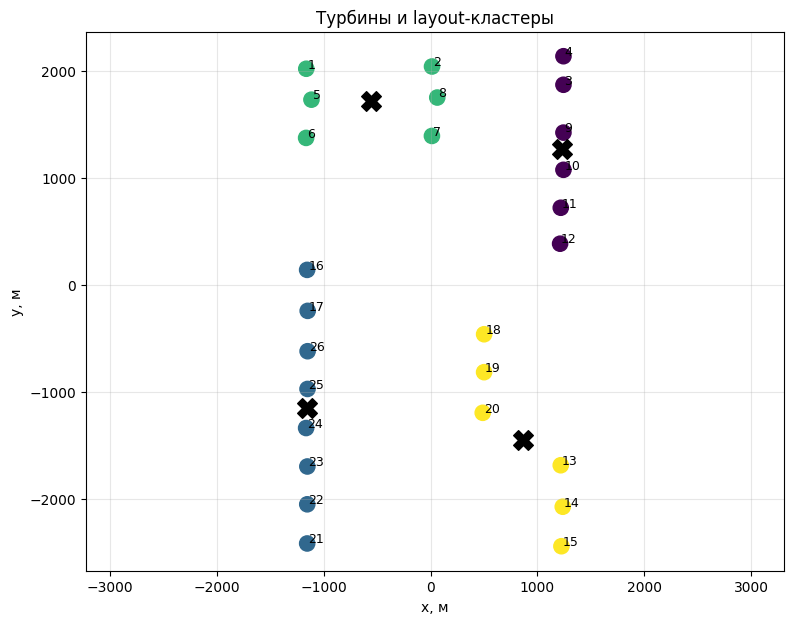

In [16]:
print("=" * 90)
print("ГЕОМЕТРИЯ ВЭС")
print("=" * 90)

if not TURBINE_COORDS_PATH.exists():
    raise FileNotFoundError(
        f"Не найден {TURBINE_COORDS_PATH}. Положи wind_farm_cords.csv в map/wind_data/"
    )

turbines = pd.read_csv(TURBINE_COORDS_PATH)

if "turbine_id" not in turbines.columns:
    turbines["turbine_id"] = np.arange(1, len(turbines) + 1)

if not {"lat", "lon"}.issubset(turbines.columns):
    raise ValueError("В файле турбин должны быть колонки lat и lon.")

lat0 = turbines["lat"].mean()
lon0 = turbines["lon"].mean()

meters_per_deg_lat = 111_320
meters_per_deg_lon = 111_320 * np.cos(np.deg2rad(lat0))

turbines["x_m"] = (turbines["lon"] - lon0) * meters_per_deg_lon
turbines["y_m"] = (turbines["lat"] - lat0) * meters_per_deg_lat

XY = turbines[["x_m", "y_m"]].to_numpy()

D = squareform(pdist(XY))
D_near = D + np.eye(len(D)) * 10**9
nearest_dist = D_near.min(axis=1)

print("Турбин:", len(turbines))
print(f"Среднее ближайшее расстояние: {nearest_dist.mean():.1f} м")
print(f"Медианное ближайшее расстояние: {np.median(nearest_dist):.1f} м")

kmeans_layout = KMeans(
    n_clusters=N_LAYOUT_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=LAYOUT_KMEANS_N_INIT,
)

turbines["layout_cluster"] = kmeans_layout.fit_predict(XY)

cluster_centers = pd.DataFrame(
    kmeans_layout.cluster_centers_,
    columns=["x_m", "y_m"],
)
cluster_centers["cluster_id"] = np.arange(len(cluster_centers))

pca_layout = PCA(n_components=2)
pca_layout.fit(XY)

main_axis = pca_layout.components_[0]
axis_angle_xy_deg = (np.rad2deg(np.arctan2(main_axis[1], main_axis[0])) + 360) % 360
farm_axis_compass_deg = (90 - axis_angle_xy_deg) % 360

print(f"Главная ось ВЭС: {farm_axis_compass_deg:.2f}° / {(farm_axis_compass_deg + 180) % 360:.2f}°")
print("Доля объяснённой дисперсии PCA:", pca_layout.explained_variance_ratio_)

cluster_axis_rows = []

for cl in sorted(turbines["layout_cluster"].unique()):
    part = turbines[turbines["layout_cluster"].eq(cl)].copy()
    XYc = part[["x_m", "y_m"]].to_numpy()

    if len(part) >= 2:
        pcac = PCA(n_components=2)
        pcac.fit(XYc)
        axis = pcac.components_[0]
        axis_xy = (np.rad2deg(np.arctan2(axis[1], axis[0])) + 360) % 360
        axis_compass = (90 - axis_xy) % 360
        evr = pcac.explained_variance_ratio_[0]
    else:
        axis_compass = np.nan
        evr = np.nan

    cluster_axis_rows.append({
        "cluster_id": cl,
        "cluster_axis_compass_deg": axis_compass,
        "cluster_axis_evr": evr,
        "n": len(part),
    })

cluster_axis_df = pd.DataFrame(cluster_axis_rows)
display(cluster_axis_df)

plt.figure(figsize=(9, 7))
plt.scatter(turbines["x_m"], turbines["y_m"], c=turbines["layout_cluster"], s=120)
plt.scatter(cluster_centers["x_m"], cluster_centers["y_m"], c="black", marker="X", s=200)

for _, row in turbines.iterrows():
    plt.text(row["x_m"] + 10, row["y_m"] + 10, str(int(row["turbine_id"])), fontsize=9)

plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Турбины и layout-кластеры")
plt.xlabel("x, м")
plt.ylabel("y, м")
plt.show()

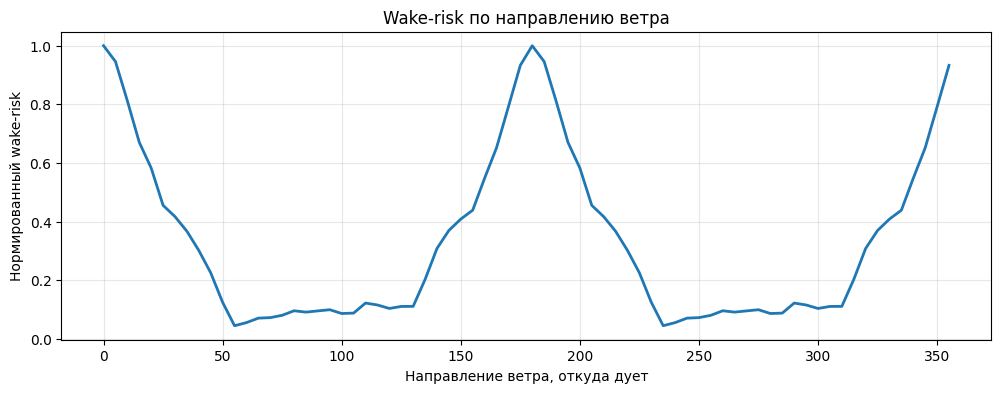

,wind_from_deg,wake_pair_count,wake_risk_score,wake_risk_score_norm
0,0,66,23.082026,1.000000
1,5,66,21.839060,0.946150
2,10,50,18.740340,0.811902
3,15,41,15.480369,0.670668
4,20,41,13.457375,0.583024


In [17]:
def compute_wake_risk_for_direction(
    xy,
    wind_from_deg,
    lateral_threshold_m=WAKE_LATERAL_THRESHOLD_M,
    max_downwind_m=WAKE_MAX_DOWNWIND_M,
    decay_downwind_m=WAKE_DECAY_DOWNWIND_M,
):
    flow_to_deg = (wind_from_deg + 180) % 360
    theta = np.deg2rad(flow_to_deg)

    flow_vec = np.array([np.sin(theta), np.cos(theta)])
    side_vec = np.array([np.cos(theta), -np.sin(theta)])

    pair_count = 0
    weighted_risk = 0.0

    n = len(xy)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            delta = xy[j] - xy[i]
            downwind = np.dot(delta, flow_vec)
            lateral = abs(np.dot(delta, side_vec))

            if downwind > 0 and downwind <= max_downwind_m and lateral <= lateral_threshold_m:
                pair_count += 1
                weighted_risk += (
                    np.exp(-downwind / decay_downwind_m)
                    * np.exp(-((lateral / lateral_threshold_m) ** 2))
                )

    return pair_count, weighted_risk


directions = np.arange(0, 360, WAKE_DIRECTION_STEP_DEG)

wake_rows = []

for direction_deg in directions:
    pair_count, risk_score = compute_wake_risk_for_direction(XY, direction_deg)
    wake_rows.append({
        "wind_from_deg": direction_deg,
        "wake_pair_count": pair_count,
        "wake_risk_score": risk_score,
    })

wake_table = pd.DataFrame(wake_rows)

if wake_table["wake_risk_score"].max() > 0:
    wake_table["wake_risk_score_norm"] = (
        wake_table["wake_risk_score"] / wake_table["wake_risk_score"].max()
    )
else:
    wake_table["wake_risk_score_norm"] = 0.0

plt.figure(figsize=(12, 4))
plt.plot(wake_table["wind_from_deg"], wake_table["wake_risk_score_norm"], linewidth=2)
plt.title("Wake-risk по направлению ветра")
plt.xlabel("Направление ветра, откуда дует")
plt.ylabel("Нормированный wake-risk")
plt.grid(alpha=0.3)
plt.show()

display(wake_table.head())

## 8. Сборка признаков cluster_axis + wake_scalar

Добавляем к `safe_features` только устойчивые spatial-признаки:

```text
cluster*_axis_alignment / crosswind
cluster_axis_alignment_mean/max/min
layout_wake_risk_scalar_120m
```

In [18]:
BEST_WAKE_FEATURE = "layout_wake_risk_scalar_120m"

In [19]:
def circular_diff_deg(a, b):
    return ((a - b + 180) % 360) - 180


def get_wind_from_deg(frame, direction_col="wind_direction_120m"):
    if direction_col not in frame.columns:
        raise ValueError(f"Нет колонки {direction_col}")
    return (pd.to_numeric(frame[direction_col], errors="coerce") * 1000) % 360


def add_cluster_axis_features(frame):
    out = frame.copy()
    added = []

    wind_from_deg = get_wind_from_deg(out, "wind_direction_120m")
    align_cols = []

    for _, row in cluster_axis_df.iterrows():
        cl = int(row["cluster_id"])
        axis = row["cluster_axis_compass_deg"]

        if np.isnan(axis):
            continue

        diff = circular_diff_deg(wind_from_deg, axis)

        col_align = f"cluster{cl}_axis_alignment"
        col_cross = f"cluster{cl}_axis_crosswind"

        out[col_align] = np.cos(2 * np.deg2rad(diff))
        out[col_cross] = np.sin(2 * np.deg2rad(diff))

        align_cols.append(col_align)
        added += [col_align, col_cross]

    if len(align_cols) > 0:
        out["cluster_axis_alignment_mean"] = out[align_cols].mean(axis=1)
        out["cluster_axis_alignment_max"] = out[align_cols].max(axis=1)
        out["cluster_axis_alignment_min"] = out[align_cols].min(axis=1)

        added += [
            "cluster_axis_alignment_mean",
            "cluster_axis_alignment_max",
            "cluster_axis_alignment_min",
        ]

    return out, added


def add_wake_scalar_feature(frame, feature_name=BEST_WAKE_FEATURE):
    out = frame.copy()
    direction_deg = get_wind_from_deg(out, "wind_direction_120m").to_numpy(dtype=float)

    wt = wake_table[["wind_from_deg", "wake_risk_score_norm"]].dropna().copy()
    wt = wt.sort_values("wind_from_deg")

    xp = wt["wind_from_deg"].to_numpy(dtype=float)
    fp = wt["wake_risk_score_norm"].to_numpy(dtype=float)

    if len(xp) == 0 or not np.isfinite(fp).any():
        out[feature_name] = 0.0
        return out, [feature_name]

    median_risk = float(np.nanmedian(fp))

    xp_wrap = np.r_[xp, xp[0] + 360.0]
    fp_wrap = np.r_[fp, fp[0]]

    direction_for_interp = np.where(np.isfinite(direction_deg), direction_deg, 0.0)

    risk = np.interp(direction_for_interp, xp_wrap, fp_wrap)
    risk[~np.isfinite(direction_deg)] = median_risk
    risk = np.nan_to_num(risk, nan=median_risk, posinf=median_risk, neginf=median_risk)
    risk = np.clip(risk, 0.0, 1.0)

    out[feature_name] = risk

    return out, [feature_name]


def build_final_frames():
    train_out = train_fe.copy()
    valid_out = valid_fe.copy()

    added_cols = []

    train_out, cluster_cols = add_cluster_axis_features(train_out)
    valid_out, _ = add_cluster_axis_features(valid_out)
    added_cols += cluster_cols

    train_out, wake_cols = add_wake_scalar_feature(train_out)
    valid_out, _ = add_wake_scalar_feature(valid_out)
    added_cols += wake_cols

    added_cols = list(dict.fromkeys([
        c for c in added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    final_feature_cols = list(dict.fromkeys([
        c for c in safe_features + added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    return train_out, valid_out, added_cols, final_feature_cols


final_train_preview, final_valid_preview, final_added_cols, final_feature_cols_preview = build_final_frames()

print("Feature set собран.")
print("train:", final_train_preview.shape)
print("valid:", final_valid_preview.shape)
print("n_added_cols:", len(final_added_cols))
print("n_features:", len(final_feature_cols_preview))
print("wake есть:", BEST_WAKE_FEATURE in final_feature_cols_preview)
print("последние добавленные:", final_added_cols[-15:])

feature_manifest = pd.DataFrame({"feature": final_feature_cols_preview})
display(feature_manifest.tail(20))

Feature set собран.
train: (32434, 184)
valid: (2126, 184)
n_added_cols: 12
n_features: 159
wake есть: True
последние добавленные: ['cluster0_axis_alignment', 'cluster0_axis_crosswind', 'cluster1_axis_alignment', 'cluster1_axis_crosswind', 'cluster2_axis_alignment', 'cluster2_axis_crosswind', 'cluster3_axis_alignment', 'cluster3_axis_crosswind', 'cluster_axis_alignment_mean', 'cluster_axis_alignment_max', 'cluster_axis_alignment_min', 'layout_wake_risk_scalar_120m']


,feature
139,wd10_openm_minus_nasa_circular
140,ws10_openm_minus_nasa
141,ws80_openm_minus_nasa50
142,cf_empirical_iso_120
143,cf_empirical_iso_80
144,p_empirical_iso_120
145,p_empirical_iso_80
146,p_empirical_iso_mean_80_120
147,cluster0_axis_alignment
148,cluster0_axis_crosswind


## 9. Опциональная локальная проверка

Проверка отключена по умолчанию, потому что этот pipeline уже зафиксирован как стабильный.  
Для быстрой проверки поставь `RUN_LOCAL_CHECK = True`.

In [20]:
RUN_LOCAL_CHECK = False
FAST_LOCAL_CHECK = True
LOCAL_SPLIT_FRAC = 0.80

In [21]:
if RUN_LOCAL_CHECK:
    print("=" * 90)
    print("LOCAL CHECK: final feature set")
    print("=" * 90)

    local_train_all, _, _, local_feature_cols = build_final_frames()

    split_idx = int(len(local_train_all) * LOCAL_SPLIT_FRAC)

    local_train_part = local_train_all.iloc[:split_idx].copy().reset_index(drop=True)
    local_eval_part = local_train_all.iloc[split_idx:].copy().reset_index(drop=True)

    y_eval = local_eval_part["target"].clip(0, INSTALLED_CAPACITY_MW).to_numpy()

    local_models = fit_ensemble(
        local_train_part,
        local_feature_cols,
        label="LOCAL_pipeline_744_clean",
        fast_mode=FAST_LOCAL_CHECK,
    )

    local_pred, local_components = predict_ensemble(
        local_models,
        local_eval_part,
        local_feature_cols,
    )

    local_mae = mean_absolute_error(y_eval, local_pred)

    local_report = pd.DataFrame([
        {
            "experiment": "pipeline_744_clean",
            "n_features": len(local_feature_cols),
            "mae": local_mae,
        }
    ])

    display(local_report)
else:
    print("Локальная проверка выключена. Для запуска поставь RUN_LOCAL_CHECK=True.")

Локальная проверка выключена. Для запуска поставь RUN_LOCAL_CHECK=True.


## 10. Финальное обучение и submission

Главная финальная ячейка: обучает полный ансамбль на всём train и сохраняет `submission_744.csv`.

In [22]:
RUN_FINAL_PIPELINE = True
PLOT_FINAL_DISTRIBUTIONS = True

FINAL PIPELINE 7.44 CLEAN
n_added_cols: 12
n_features: 159
wake-признак: layout_wake_risk_scalar_120m
wake есть в feature_cols: True

Обучение ансамбля: FINAL_pipeline_744_clean
n_features: 159
Submission сохранён: outputs\pipeline_744\submission_744.csv
Размер: (2126, 1)


,target
0,5.776778
1,14.790994
2,16.716997
3,15.898618
4,13.458952


,target
count,2126.000000
mean,39.763244
std,25.588847
min,0.000000
25%,14.544312
50%,40.739831
75%,64.695286
max,79.477235



Распределение предсказаний компонентов:


,cat_mae_direct,xgb_residual,lgb_residual,hgb_q545,hgb_q570,hgb_q530,blend
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,39.182321,39.825257,39.810557,40.151057,40.638497,39.825868,39.763244
std,25.474935,25.868154,25.942393,25.605826,25.577191,25.583981,25.588847
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.907961,14.051699,13.847773,14.550772,15.566422,14.556577,14.544312
50%,40.234365,40.794599,40.291226,41.561886,41.899976,40.847445,40.739831
75%,63.911195,65.133796,65.360638,64.969202,65.515457,64.948823,64.695286
max,79.087339,81.142914,80.955051,80.067783,79.247089,79.368645,79.477235


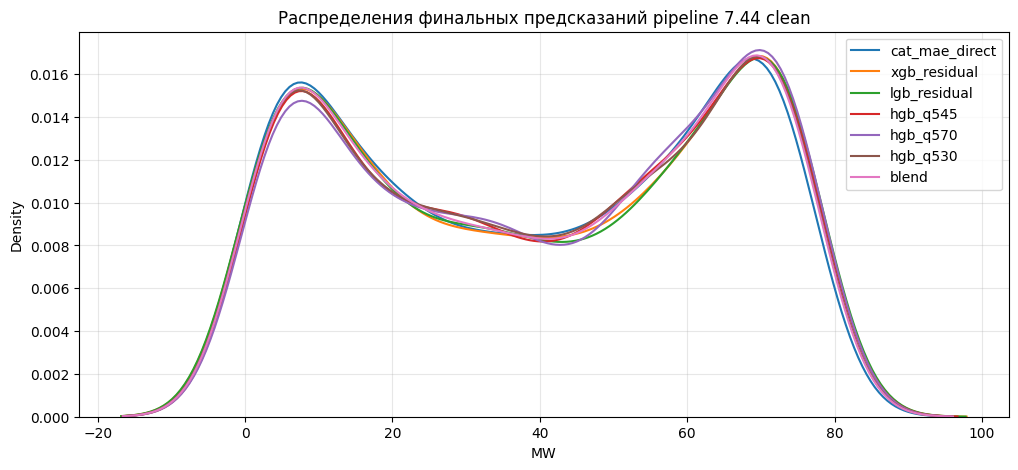

In [ ]:
if RUN_FINAL_PIPELINE:
    print("=" * 90)
    print("FINAL PIPELINE 7.44 CLEAN")
    print("=" * 90)

    final_train, final_valid, final_added_cols, final_feature_cols = build_final_frames()

    print("n_added_cols:", len(final_added_cols))
    print("n_features:", len(final_feature_cols))
    print("wake-признак:", BEST_WAKE_FEATURE)
    print("wake есть в feature_cols:", BEST_WAKE_FEATURE in final_feature_cols)

    final_models = fit_ensemble(
        final_train,
        final_feature_cols,
        label="FINAL_pipeline_744_clean",
        fast_mode=False,
    )

    final_pred, final_components = predict_ensemble(
        final_models,
        final_valid,
        final_feature_cols,
    )

    submission = final_valid[["row_id"]].copy()
    submission["target"] = final_pred

    submission = (
        submission
        .sort_values("row_id")[["target"]]
        .reset_index(drop=True)
    )

    submission.to_csv(SUBMISSION_PATH, index=False)

    print("Submission сохранён:", SUBMISSION_PATH)
    print("Размер:", submission.shape)

    display(submission.head())
    display(submission.describe())

    component_df = pd.DataFrame(final_components)
    component_df["blend"] = submission["target"].to_numpy()

    print("\nРаспределение предсказаний компонентов:")
    display(component_df.describe())

else:
    print("Финальное обучение выключено. Для запуска поставь RUN_FINAL_PIPELINE=True.")

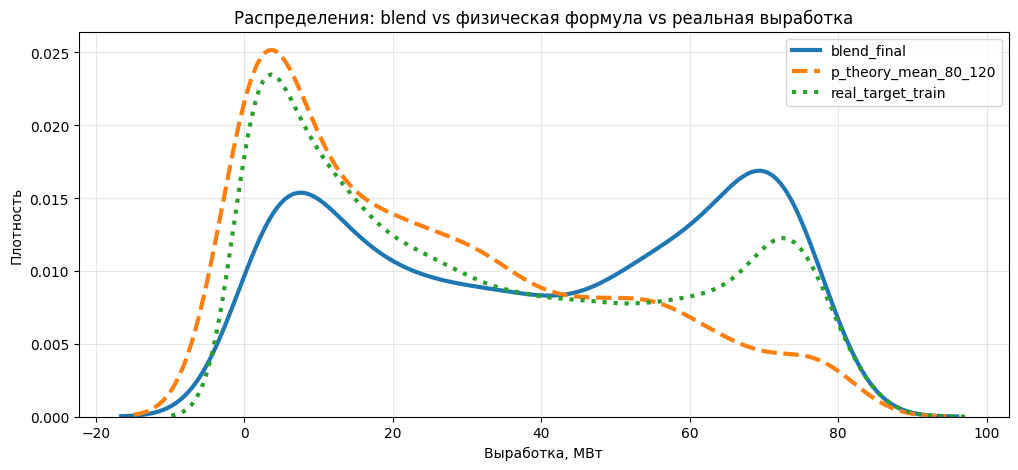

Сравнение распределений по бинам: blend vs theory vs real


,power_bin,count,mean,median,min_value,max_value,share,source
0,0-1,30,0.381351,0.268506,0.000000,0.929971,0.014111,blend_final
1,1-5,190,2.979837,3.028697,1.032547,4.957558,0.089370,blend_final
2,5-10,184,7.410608,7.445711,5.050545,9.968090,0.086548,blend_final
3,10-20,262,14.647546,14.762029,10.038039,19.773168,0.123236,blend_final
4,20-40,388,29.900192,29.618892,20.065523,39.935462,0.182502,blend_final
5,40-60,406,51.155721,51.835865,40.110059,59.963365,0.190969,blend_final
6,60-80,666,69.650660,70.128924,60.021799,79.477235,0.313264,blend_final
7,0-1,266,0.157007,0.000000,0.000000,0.993881,0.125118,p_theory_mean_80_120
8,1-5,252,2.819296,2.662929,1.006108,4.995777,0.118532,p_theory_mean_80_120
9,5-10,236,7.234880,7.140594,5.024501,9.984118,0.111007,p_theory_mean_80_120


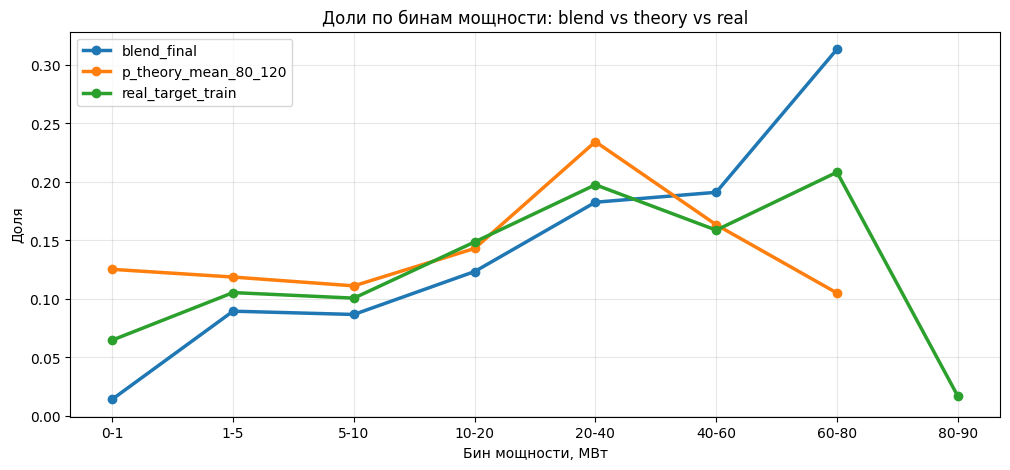

In [34]:
if PLOT_FINAL_DISTRIBUTIONS:
    # ============================================================
    # РАСПРЕДЕЛЕНИЯ: final blend vs физическая формула vs реальность
    # ============================================================

    # ------------------------------------------------------------
    # 1. Итоговый прогноз ансамбля
    # ------------------------------------------------------------

    blend_values = pd.Series(
        submission["target"].to_numpy(),
        name="blend_final"
    ).clip(0, INSTALLED_CAPACITY_MW)

    # ------------------------------------------------------------
    # 2. Теоретическая физическая формула
    # ------------------------------------------------------------

    theory_col = None

    for c in ["p_theory_mean_80_120", "p_theory_120", "p_theory_80"]:
        if c in final_valid.columns:
            theory_col = c
            break

    if theory_col is None:
        raise ValueError("Не нашёл p_theory_mean_80_120 / p_theory_120 / p_theory_80 в final_valid.")

    theory_values = pd.Series(
        final_valid[theory_col].to_numpy(),
        name=theory_col
    ).clip(0, INSTALLED_CAPACITY_MW)

    # ------------------------------------------------------------
    # 3. Реальная выработка
    # В final_valid target нет, поэтому:
    # - если есть diag_df, берём local-valid факт
    # - иначе берём train target
    # ------------------------------------------------------------

    if "diag_df" in globals() and "y_true" in diag_df.columns:
        real_values = pd.Series(
            diag_df["y_true"].to_numpy(),
            name="real_y_true_local_valid"
        ).clip(0, INSTALLED_CAPACITY_MW)
        real_label = "real_y_true_local_valid"
    else:
        real_values = pd.Series(
            final_train["target"].to_numpy(),
            name="real_target_train"
        ).clip(0, INSTALLED_CAPACITY_MW)
        real_label = "real_target_train"

    # ------------------------------------------------------------
    # 4. KDE-график: только 3 линии
    # ------------------------------------------------------------

    plt.figure(figsize=(12, 5))

    sns.kdeplot(
        blend_values,
        label="blend_final",
        linewidth=3,
    )

    sns.kdeplot(
        theory_values,
        label=theory_col,
        linewidth=3,
        linestyle="--",
    )

    sns.kdeplot(
        real_values,
        label=real_label,
        linewidth=3,
        linestyle=":",
    )

    plt.title("Распределения: blend vs физическая формула vs реальная выработка")
    plt.xlabel("Выработка, МВт")
    plt.ylabel("Плотность")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # ------------------------------------------------------------
    # 5. Бины: blend vs theory vs real
    # ------------------------------------------------------------

    power_bins = [0, 1, 5, 10, 20, 40, 60, 80, 91]
    power_labels = [
        "0-1",
        "1-5",
        "5-10",
        "10-20",
        "20-40",
        "40-60",
        "60-80",
        "80-90",
    ]

    def make_power_bin_report(values, source_name):
        temp = pd.DataFrame({
            "value": pd.Series(values).clip(0, INSTALLED_CAPACITY_MW)
        })

        temp["power_bin"] = pd.cut(
            temp["value"],
            bins=power_bins,
            labels=power_labels,
            include_lowest=True,
        )

        report = (
            temp
            .groupby("power_bin", observed=True)
            .agg(
                count=("value", "size"),
                mean=("value", "mean"),
                median=("value", "median"),
                min_value=("value", "min"),
                max_value=("value", "max"),
            )
            .reset_index()
        )

        report["share"] = report["count"] / report["count"].sum()
        report["source"] = source_name

        return report

    blend_bin_report = make_power_bin_report(
        blend_values,
        "blend_final",
    )

    theory_bin_report = make_power_bin_report(
        theory_values,
        theory_col,
    )

    real_bin_report = make_power_bin_report(
        real_values,
        real_label,
    )

    distribution_compare = pd.concat(
        [
            blend_bin_report,
            theory_bin_report,
            real_bin_report,
        ],
        ignore_index=True,
        sort=False,
    )

    print("Сравнение распределений по бинам: blend vs theory vs real")
    display(distribution_compare)

    # ------------------------------------------------------------
    # 6. График долей по бинам
    # ------------------------------------------------------------

    plt.figure(figsize=(12, 5))

    for source, part in distribution_compare.groupby("source"):
        plt.plot(
            part["power_bin"].astype(str),
            part["share"],
            marker="o",
            linewidth=2.5,
            label=source,
        )

    plt.title("Доли по бинам мощности: blend vs theory vs real")
    plt.xlabel("Бин мощности, МВт")
    plt.ylabel("Доля")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

## 11. Проверка итогового файла

In [24]:
print("=" * 90)
print("ФИНАЛЬНАЯ ПРОВЕРКА ФАЙЛА")
print("=" * 90)

print("Файл:", SUBMISSION_PATH)
print("существует:", SUBMISSION_PATH.exists())

if SUBMISSION_PATH.exists():
    sub = pd.read_csv(SUBMISSION_PATH)
    print("размер:", sub.shape)
    display(sub.head())
    display(sub.describe())

ФИНАЛЬНАЯ ПРОВЕРКА ФАЙЛА
Файл: outputs\pipeline_744\submission_744.csv
существует: True
размер: (2126, 1)


,target
0,5.776778
1,14.790994
2,16.716997
3,15.898618
4,13.458952


,target
count,2126.000000
mean,39.763244
std,25.588847
min,0.000000
25%,14.544312
50%,40.739831
75%,64.695286
max,79.477235


## 12. Короткая диагностика кривой мощности

In [27]:
RUN_POWER_CURVE_DIAGNOSTIC = True
POWER_CURVE_MIN_BIN_COUNT = 10
POWER_CURVE_SPEED_BINS = np.arange(0, 26.5, 0.5)


Обучение ансамбля: DIAG_pipeline_744_clean
n_features: 159


,speed_bin,count,speed_mean,fact_mean,fact_median,pred_mean,mae,bias
18,"(9.0, 9.5]",270,9.262296,48.292993,52.0530,50.610557,11.495832,2.317564
19,"(9.5, 10.0]",222,9.745315,49.162374,50.0925,54.445308,11.046897,5.282934
17,"(8.5, 9.0]",301,8.760963,45.170478,45.5170,45.740877,10.451978,0.570399
15,"(7.5, 8.0]",327,7.743364,36.978667,37.7340,36.317619,10.373339,-0.661048
21,"(10.5, 11.0]",172,10.726047,57.978267,62.9295,62.140546,10.239064,4.162278
16,"(8.0, 8.5]",324,8.262006,39.550052,39.7095,40.824167,10.171668,1.274114
14,"(7.0, 7.5]",363,7.259008,31.773187,29.8330,30.203824,10.073126,-1.569363
20,"(10.0, 10.5]",214,10.224019,55.279790,58.1815,58.710103,9.701286,3.430313
25,"(12.5, 13.0]",68,12.746471,63.814132,69.2750,71.460876,9.605504,7.646744
13,"(6.5, 7.0]",385,6.750208,26.622135,25.0380,24.907026,9.271959,-1.715109


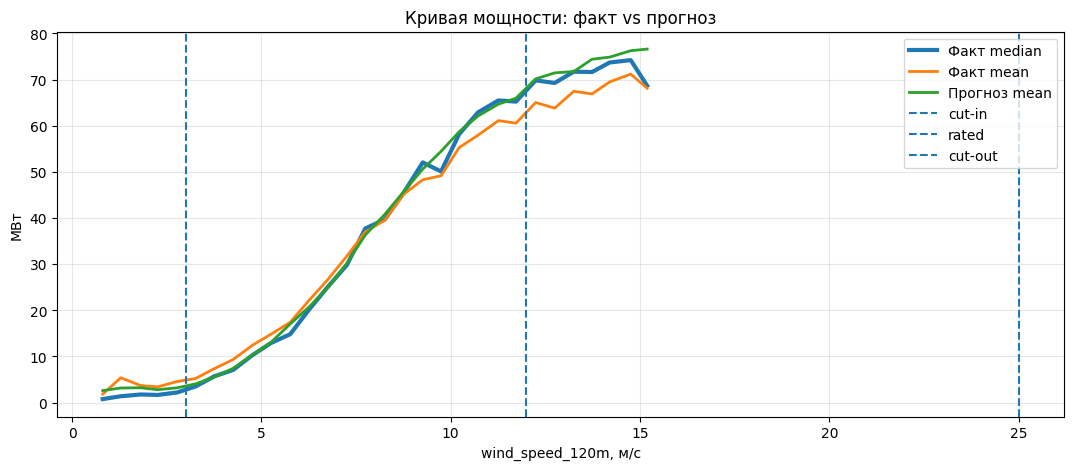

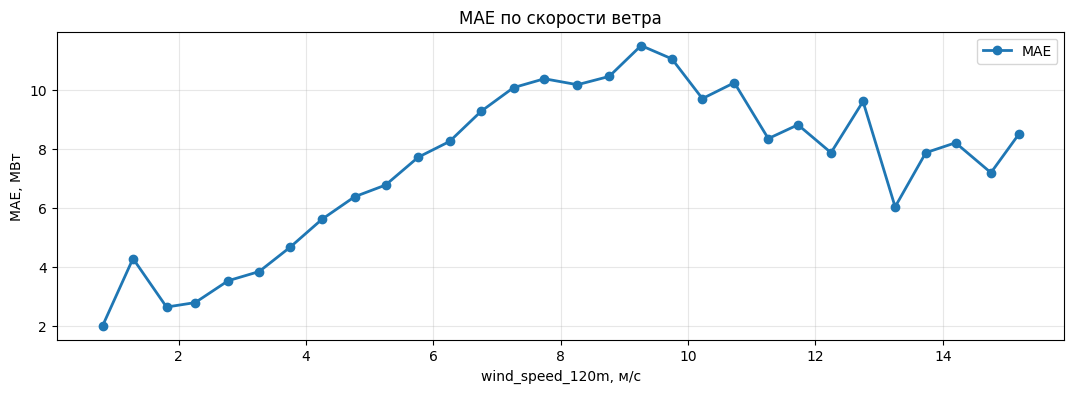

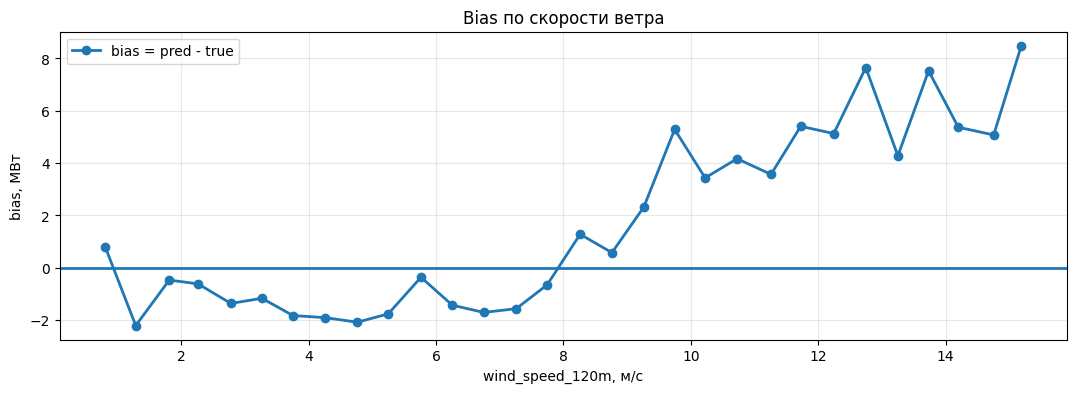

In [28]:
if RUN_POWER_CURVE_DIAGNOSTIC:
    if "final_train" not in globals() or "final_models" not in globals():
        raise NameError("Сначала выполни финальное обучение или собери final_train/final_models.")

    diag_split_idx = int(len(final_train) * 0.8)
    diag_train_part = final_train.iloc[:diag_split_idx].copy().reset_index(drop=True)
    diag_eval_part = final_train.iloc[diag_split_idx:].copy().reset_index(drop=True)

    diag_models = fit_ensemble(
        diag_train_part,
        final_feature_cols,
        label="DIAG_pipeline_744_clean",
        fast_mode=True,
    )

    diag_pred, _ = predict_ensemble(
        diag_models,
        diag_eval_part,
        final_feature_cols,
    )

    pc_df = diag_eval_part.copy()
    pc_df["y_true"] = pc_df["target"].clip(0, INSTALLED_CAPACITY_MW)
    pc_df["y_pred"] = np.clip(diag_pred, 0, INSTALLED_CAPACITY_MW)
    pc_df["error"] = pc_df["y_pred"] - pc_df["y_true"]
    pc_df["abs_error"] = pc_df["error"].abs()

    pc_df["speed_bin"] = pd.cut(
        pc_df["wind_speed_120m"],
        bins=POWER_CURVE_SPEED_BINS,
        include_lowest=True,
    )

    curve_report = (
        pc_df
        .groupby("speed_bin", observed=True)
        .agg(
            count=("y_true", "size"),
            speed_mean=("wind_speed_120m", "mean"),
            fact_mean=("y_true", "mean"),
            fact_median=("y_true", "median"),
            pred_mean=("y_pred", "mean"),
            mae=("abs_error", "mean"),
            bias=("error", "mean"),
        )
        .reset_index()
    )

    curve_report = curve_report[curve_report["count"] >= POWER_CURVE_MIN_BIN_COUNT].copy()

    display(curve_report.sort_values("mae", ascending=False).head(15))

    plt.figure(figsize=(13, 5))
    plt.plot(curve_report["speed_mean"], curve_report["fact_median"], linewidth=3, label="Факт median")
    plt.plot(curve_report["speed_mean"], curve_report["fact_mean"], linewidth=2, label="Факт mean")
    plt.plot(curve_report["speed_mean"], curve_report["pred_mean"], linewidth=2, label="Прогноз mean")
    plt.axvline(CUT_IN_SPEED, linestyle="--", linewidth=1.5, label="cut-in")
    plt.axvline(RATED_SPEED, linestyle="--", linewidth=1.5, label="rated")
    plt.axvline(CUT_OUT_SPEED, linestyle="--", linewidth=1.5, label="cut-out")
    plt.title("Кривая мощности: факт vs прогноз")
    plt.xlabel("wind_speed_120m, м/с")
    plt.ylabel("МВт")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(13, 4))
    plt.plot(curve_report["speed_mean"], curve_report["mae"], marker="o", linewidth=2, label="MAE")
    plt.title("MAE по скорости ветра")
    plt.xlabel("wind_speed_120m, м/с")
    plt.ylabel("MAE, МВт")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(13, 4))
    plt.plot(curve_report["speed_mean"], curve_report["bias"], marker="o", linewidth=2, label="bias = pred - true")
    plt.axhline(0, linewidth=2)
    plt.title("Bias по скорости ветра")
    plt.xlabel("wind_speed_120m, м/с")
    plt.ylabel("bias, МВт")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Диагностика кривой мощности выключена. Для запуска поставь RUN_POWER_CURVE_DIAGNOSTIC=True.")